# 📘 Session 14: Exploratory Data Analysis (EDA)
### Duration: ~2.5 Hours

---

**Topics Covered:**
1. What Is EDA and Where It Fits in the Data Science Workflow
2. A Structured EDA Workflow and Checklist
3. Data Quality Audit — First Look at Any Dataset
4. Univariate EDA — One Variable at a Time
5. Bivariate and Segmented EDA — Relationships and Groups
6. Multivariate EDA — Patterns Across Many Columns
7. From EDA to Next Steps — Hypotheses, Cleaning, and Modeling Prep

---

**Why This Session Matters for Data Science:**
- **EDA is how you understand data before trusting any model**
- **Most project risk** (bad joins, leakage, wrong units, silent missingness) is caught here
- **Feature ideas and business questions** emerge from systematic exploration, not guesswork
- **Stakeholder communication** improves when you can show evidence-backed patterns

> Sessions 11–13 gave you **tools** (plots, summaries, correlation). This session teaches **how to use them as a process**. Session 15 will apply everything in a **full end-to-end EDA demo project** — not in this notebook.

**Libraries:** `pandas`, `numpy`, `matplotlib`, `seaborn` (same stack as Sessions 11–13).


---
## 1. What Is EDA and Where It Fits

**Exploratory Data Analysis (EDA)** is iterative investigation of a dataset to summarize structure, spot anomalies, test assumptions, and generate questions — usually **before** formal modeling.

### EDA vs other phases

| Phase | Goal | Typical outputs |
|-------|------|-----------------|
| **Data collection / ingestion** | Get raw tables into the workspace | CSV, DB extract, API pull |
| **EDA (this session)** | Understand quality, distributions, relationships | Notes, plots, issue list, hypotheses |
| **Cleaning / feature engineering** | Fix issues EDA surfaced | Clean DataFrame, new columns |
| **Modeling** | Predict or explain with algorithms | Metrics, coefficients, feature importances |
| **Deployment / monitoring** | Use model in production; watch drift | Pipelines, dashboards |

### Types of EDA questions

| Question type | Examples |
|---------------|----------|
| **Structure** | How many rows/columns? What are the keys? |
| **Quality** | Missing values? Duplicates? Wrong dtypes? |
| **Distribution** | Skew? Outliers? Rare categories? |
| **Relationship** | Does X move with Y? By segment? |
| **Segmentation** | Do patterns differ by region, cohort, time? |
| **Action** | What should we clean, transform, or collect next? |

> ⚠️ **Special Case — EDA is not “one pass”**: You loop back after cleaning, joins, or new columns. Treat EDA as **ongoing**, not a single notebook cell run.

> **Data Science relevance**: Strong EDA reduces wasted modeling time and prevents “garbage in, garbage out.”


---
## 2. A Structured EDA Workflow

Use a **repeatable checklist** so no dataset gets a random subset of plots.

### Recommended order

```
1. Context     → business question, row grain, data dictionary
2. Load & shape → .head(), .info(), .shape, memory
3. Quality      → missing, duplicates, invalid ranges, dtypes
4. Univariate   → each important column alone
5. Bivariate    → target vs features; feature vs feature
6. Multivariate → correlation, pair plots, faceted views
7. Synthesize   → findings, risks, cleaning list, modeling notes
```

### Question-driven EDA template

| Step | Ask yourself | pandas / viz |
|------|--------------|--------------|
| Grain | One row = ? | `df.head()`, docs |
| Keys | Unique ID? | `df.duplicated()`, `nunique()` |
| Targets | What are we predicting/explaining? | mark `y` column early |
| Leakage | Any column that wouldn’t exist at prediction time? | domain review |
| Segments | Known groups to compare? | `groupby`, faceted plots |

### What to document (minimum)

- **Dataset**: source, date range, row count, known limitations
- **Issues**: missing %, outliers, inconsistent categories
- **Findings**: 3–5 bullet insights backed by a stat or plot
- **Next steps**: clean, transform, features to try, open questions

> ⚠️ **Special Case — confirmation bias**: Don’t only plot what you expect. Scan **all** numeric and high-cardinality columns at least once.

> **Session 15 preview**: You will run this full workflow on one real dataset from load → report. Here we practice **each step in isolation** on small examples.


In [3]:
# --- Shared setup for this session ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")

# We'll use tips (restaurant bills) as a running example — small, messy enough for teaching
tips = sns.load_dataset("tips")
print("Shape:", tips.shape)
print("\nColumns:", list(tips.columns))
print("\nFirst rows:")
print(tips.head(20))


Shape: (244, 7)

Columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

First rows:
    total_bill   tip     sex smoker  day    time  size
0        16.99  1.01  Female     No  Sun  Dinner     2
1        10.34  1.66    Male     No  Sun  Dinner     3
2        21.01  3.50    Male     No  Sun  Dinner     3
3        23.68  3.31    Male     No  Sun  Dinner     2
4        24.59  3.61  Female     No  Sun  Dinner     4
5        25.29  4.71    Male     No  Sun  Dinner     4
6         8.77  2.00    Male     No  Sun  Dinner     2
7        26.88  3.12    Male     No  Sun  Dinner     4
8        15.04  1.96    Male     No  Sun  Dinner     2
9        14.78  3.23    Male     No  Sun  Dinner     2
10       10.27  1.71    Male     No  Sun  Dinner     2
11       35.26  5.00  Female     No  Sun  Dinner     4
12       15.42  1.57    Male     No  Sun  Dinner     2
13       18.43  3.00    Male     No  Sun  Dinner     4
14       14.83  3.02  Female     No  Sun  Dinner     2
15       21.58  3.9

---
## 3. Data Quality Audit — First Look at Any Dataset

Before plots, run a **quality pass**. This catches 80% of silent failures.

### Essential checks

| Check | Method | Why |
|-------|--------|-----|
| Shape & dtypes | `.info()`, `.dtypes` | Wrong types break stats/plots |
| Missing | `.isna().sum()`, `%` | MCAR vs systematic missing |
| Duplicates | `.duplicated().sum()` | Inflated counts, bad joins |
| Cardinality | `.nunique()` per column | IDs vs categories |
| Numeric sanity | min/max, negatives where impossible | Unit errors |
| Category sanity | `value_counts()` | typos, inconsistent labels |

### Quick audit helper pattern

```python
def audit_frame(df):
    report = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'non_null': df.notna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
        'nunique': df.nunique(),
    })
    return report.sort_values('missing_pct', ascending=False)
```

> ⚠️ **Special Case — `object` dtype**: Often means strings *or* mixed types. Use `.apply(type)` on a sample if suspicious.

> **Data Science relevance**: Document every quality issue; cleaning priorities come from **impact on the business question**, not aesthetics.


In [4]:
def audit_frame(df):
    return (
        pd.DataFrame({
            "dtype": df.dtypes.astype(str),
            "non_null": df.notna().sum(),
            "missing_pct": (df.isna().mean() * 100).round(2),
            "nunique": df.nunique(),
        })
        .sort_values("missing_pct", ascending=False)
    )

print("=== Audit report ===")
print(audit_frame(tips))
print("\nDuplicate rows:", tips.duplicated().sum())
print("\nTotal bill range:", tips["total_bill"].min(), "→", tips["total_bill"].max())
print("Tip range:", tips["tip"].min(), "→", tips["tip"].max())

# Inject a teaching issue: pretend one row has a typo in 'day'
tips_eda = tips.copy()
tips_eda.loc[0, "day"] = "Thur"  # trailing space — common real-world problem
print("\nUnique 'day' values (watch for typos):")
print(tips_eda["day"].value_counts())


=== Audit report ===
               dtype  non_null  missing_pct  nunique
total_bill   float64       244          0.0      229
tip          float64       244          0.0      123
sex         category       244          0.0        2
smoker      category       244          0.0        2
day         category       244          0.0        4
time        category       244          0.0        2
size           int64       244          0.0        6

Duplicate rows: 1

Total bill range: 3.07 → 50.81
Tip range: 1.0 → 10.0

Unique 'day' values (watch for typos):
day
Sat     87
Sun     75
Thur    63
Fri     19
Name: count, dtype: int64


---
## 4. Univariate EDA — One Variable at a Time

Understand each column **before** combining them.

### Numeric columns

| Tool | Purpose |
|------|---------|
| `describe()` | center, spread, quartiles |
| Histogram / KDE | shape, skew, multimodality |
| Box plot | outliers vs bulk |

### Categorical columns

| Tool | Purpose |
|------|---------|
| `value_counts(normalize=True)` | frequency & imbalance |
| Bar chart | visual category balance |
| Rare levels | flag categories with very low count |

### Choosing summary vs plot

| Situation | Prefer |
|-----------|--------|
| Reporting to stakeholders | `describe()` + one clear plot |
| Skewed revenue/cost | median + IQR + log-scale hist |
| High-cardinality text | top-N `value_counts`, not full bar chart |

> **Data Science relevance**: Univariate profiles tell you which transforms (log, clip, one-hot) you'll need later.


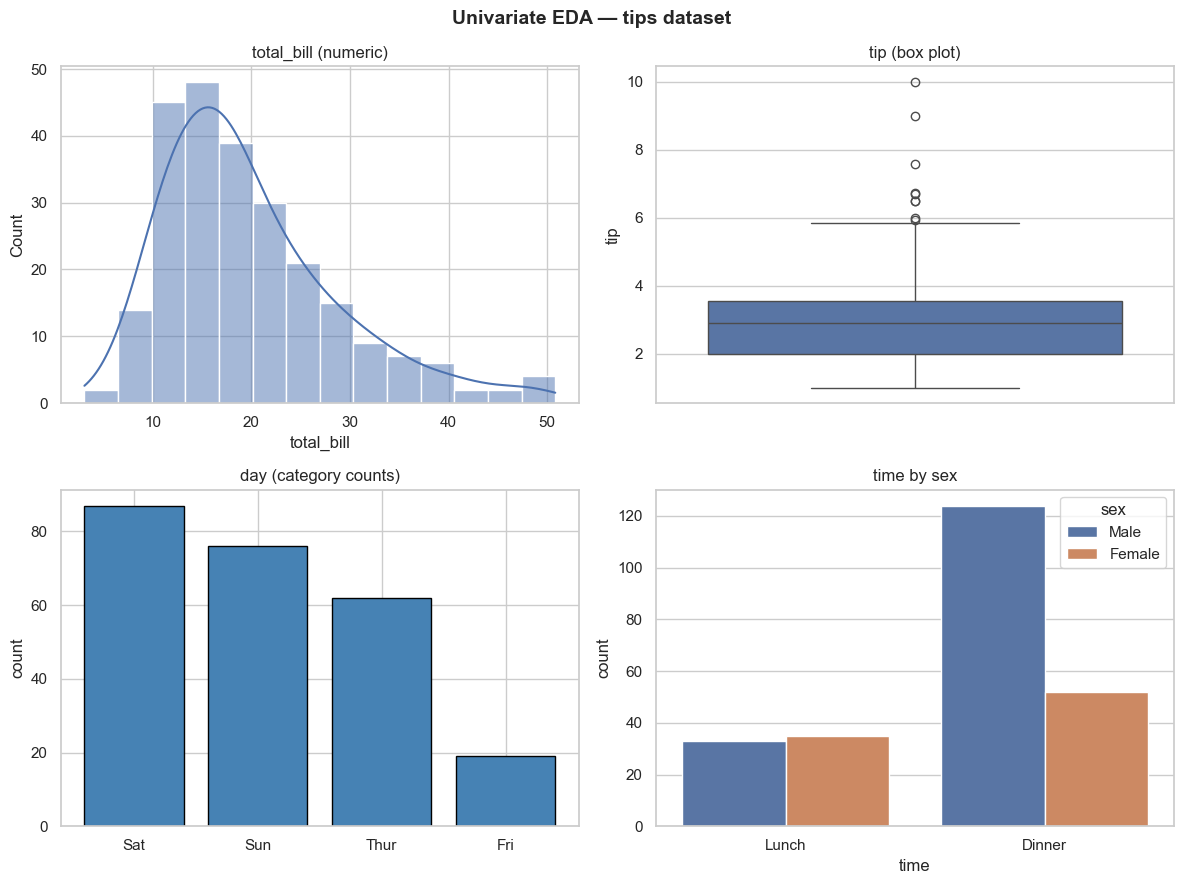

Numeric summary:
        total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000

Categorical proportions (day):
 day
Sat     0.357
Sun     0.311
Thur    0.254
Fri     0.078
Name: proportion, dtype: float64


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Univariate EDA — tips dataset", fontsize=14, fontweight="bold")

# Numeric: total_bill
sns.histplot(data=tips, x="total_bill", kde=True, ax=axes[0, 0])
axes[0, 0].set_title("total_bill (numeric)")

# Numeric: tip
sns.boxplot(data=tips, y="tip", ax=axes[0, 1])
axes[0, 1].set_title("tip (box plot)")

# Categorical: day
day_counts = tips["day"].value_counts()
axes[1, 0].bar(day_counts.index, day_counts.values, color="steelblue", edgecolor="black")
axes[1, 0].set_title("day (category counts)")
axes[1, 0].set_ylabel("count")

# Categorical: time
sns.countplot(data=tips, x="time", hue="sex", ax=axes[1, 1])
axes[1, 1].set_title("time by sex")

plt.tight_layout()
plt.show()

print("Numeric summary:\n", tips[["total_bill", "tip", "size"]].describe())
print("\nCategorical proportions (day):\n", tips["day"].value_counts(normalize=True).round(3))


---
## 5. Bivariate and Segmented EDA

Once you know individual columns, ask **how they relate** — overall and **within segments**.

### Common bivariate views

| X type | Y type | Plot |
|--------|--------|------|
| Numeric | Numeric | scatter, regplot, hexbin (large n) |
| Categorical | Numeric | box, violin, bar of means |
| Categorical | Categorical | crosstab, stacked bar, heatmap of counts |
| Time | Numeric | line plot |

### Segmentation (`groupby`, `hue`, facets)

| Technique | When |
|-----------|------|
| `hue=` in seaborn | Compare 1–2 groups on same axes |
| `groupby().agg()` | Table of mean/median/count per segment |
| FacetGrid / `col=` | Same plot repeated per category |

### Derived metrics (often useful in EDA)

```python
tips['tip_pct'] = tips['tip'] / tips['total_bill'] * 100
```

> ⚠️ **Special Case — Simpson's paradox**: A trend overall can **reverse** within groups. Always check key segments (region, cohort, time).

> **Data Science relevance**: Bivariate EDA suggests features (ratios, interactions) and warns about confounding.


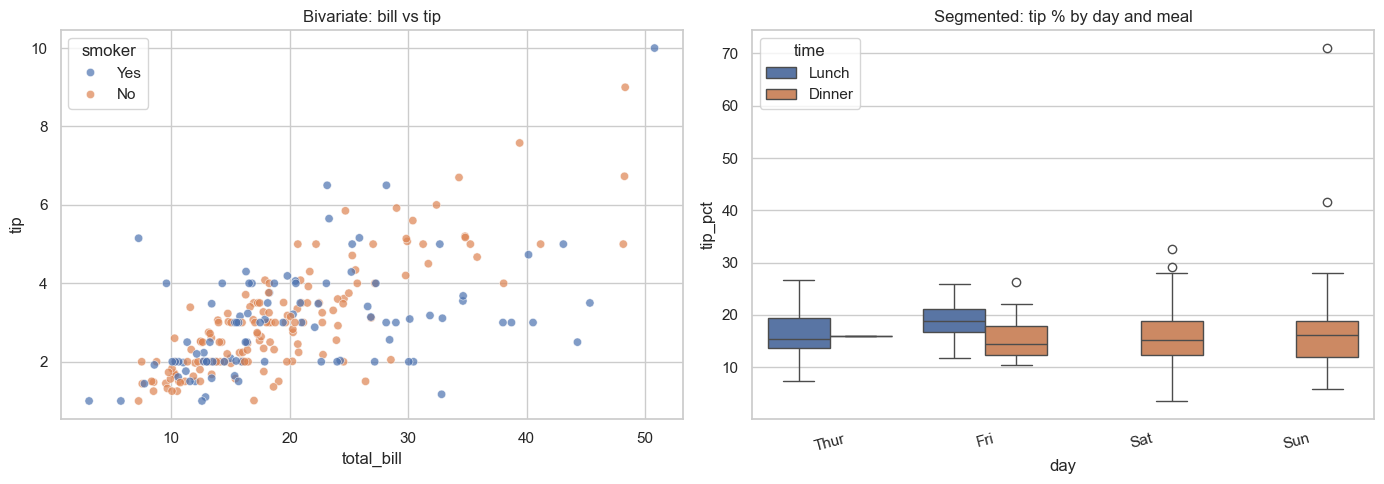

tip_pct by day × time:
               mean  median  count
day  time                        
Thur Lunch   16.13   15.38     61
     Dinner  15.97   15.97      1
Fri  Lunch   18.88   18.77      7
     Dinner  15.89   14.47     12
Sat  Dinner  15.32   15.18     87
Sun  Dinner  16.69   16.11     76


In [6]:
# Derived feature for exploration
tips = tips.copy()
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=tips, x="total_bill", y="tip", hue="smoker", alpha=0.7, ax=axes[0])
axes[0].set_title("Bivariate: bill vs tip")

sns.boxplot(data=tips, x="day", y="tip_pct", hue="time", ax=axes[1])
axes[1].set_title("Segmented: tip % by day and meal")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Table: average tip_pct by segment
seg = (
    tips.groupby(["day", "time"], observed=True)["tip_pct"]
    .agg(["mean", "median", "count"])
    .round(2)
)
print("tip_pct by day × time:\n", seg)


---
## 6. Multivariate EDA — Many Columns Together

Multivariate EDA finds **redundancy**, **clusters of related features**, and **multivariate outliers**.

### Tools

| Tool | Purpose |
|------|---------|
| Correlation heatmap | linear/monotonic redundancy (numeric) |
| `pairplot` / `PairGrid` | all-pairs scan (small feature sets) |
| Faceted histograms | distribution shifts across groups |
| Crosstab + normalize | association between categoricals |

### Practical limits

| # features | Strategy |
|------------|----------|
| ≤ 8 numeric | pairplot or full corr heatmap |
| 9–30 numeric | corr heatmap + focus pairs with |r| > 0.7 |
| 30+ | correlation on subset; consider PCA later (future session) |

> ⚠️ **Special Case — high correlation ≠ remove**: Two correlated features may both be causal; discuss with domain experts before dropping.

> **Data Science relevance**: Multivariate EDA informs feature selection, regularization, and multicollinearity checks for linear models.


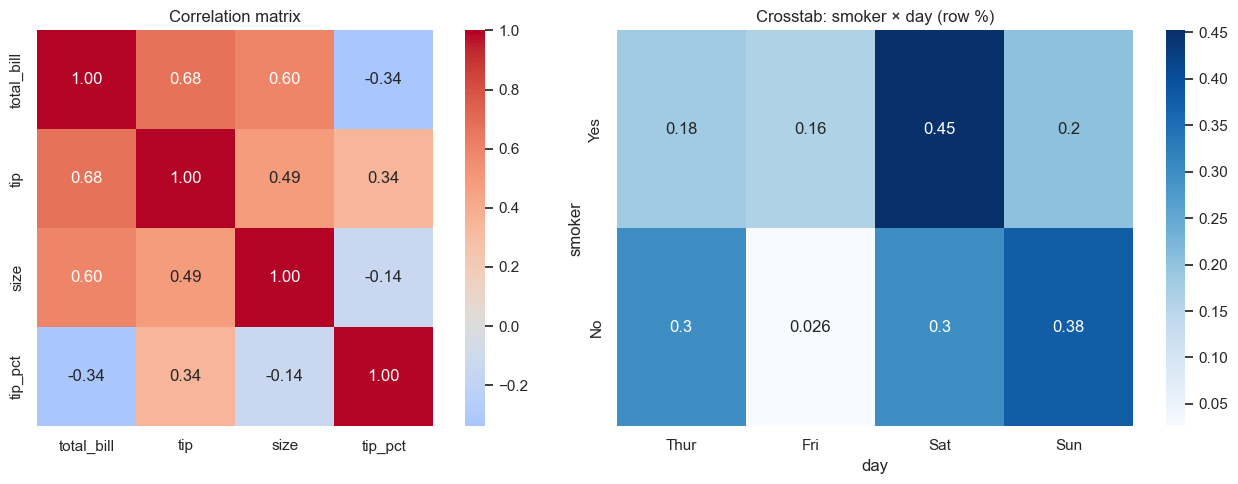

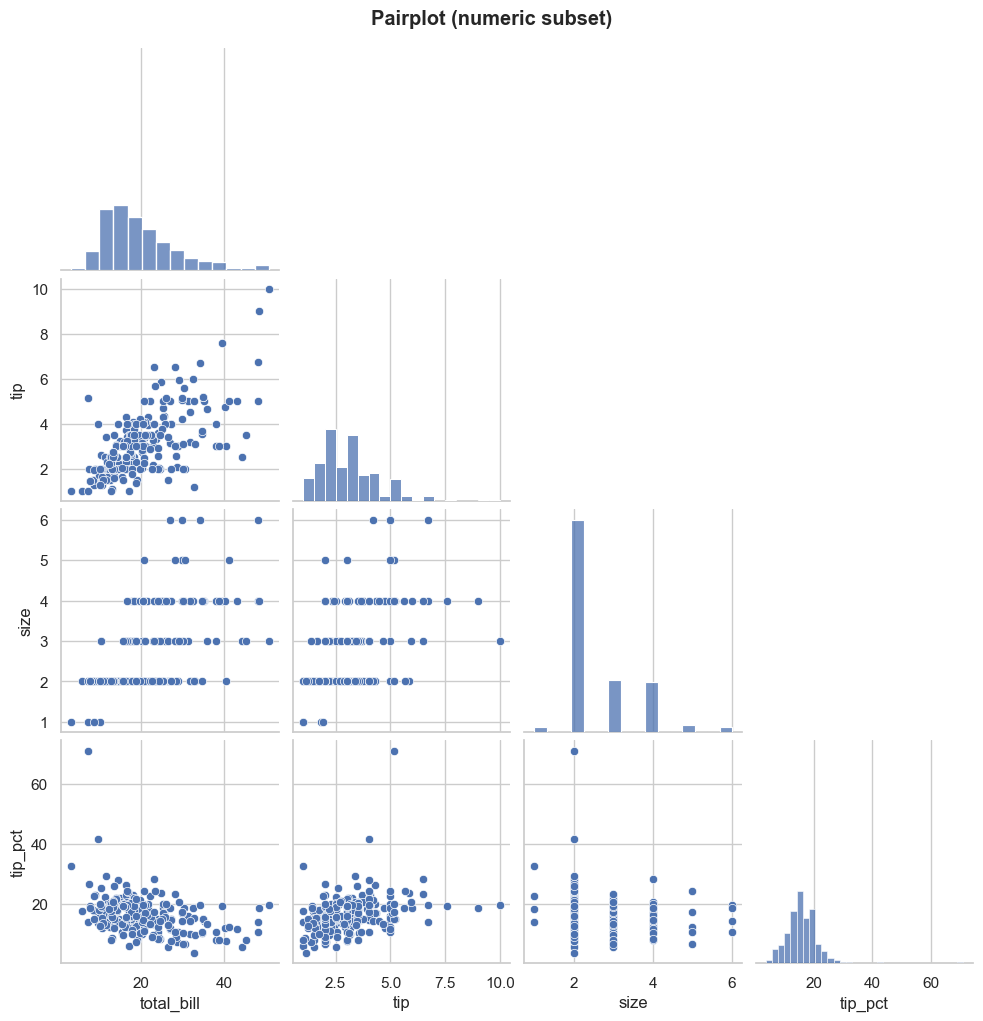

In [7]:
# Multivariate on numeric columns
num_cols = ["total_bill", "tip", "size", "tip_pct"]
corr = tips[num_cols].corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0], square=True)
axes[0].set_title("Correlation matrix")

# Crosstab: smoker vs day (normalized by row)
ct = pd.crosstab(tips["smoker"], tips["day"], normalize="index").round(3)
sns.heatmap(ct, annot=True, cmap="Blues", ax=axes[1])
axes[1].set_title("Crosstab: smoker × day (row %)")

plt.tight_layout()
plt.show()

# Quick pairplot on a subset (keep small for teaching)
g = sns.pairplot(tips[["total_bill", "tip", "size", "tip_pct"]], corner=True, diag_kind="hist")
g.fig.suptitle("Pairplot (numeric subset)", y=1.02, fontweight="bold")
plt.show()


---
## 7. From EDA to Next Steps

EDA should **end with decisions**, not an endless gallery of charts.

### EDA deliverable template (use in Session 15)

```markdown
## Dataset
- Source, rows, columns, date range

## Quality issues
- [ ] missing: ...
- [ ] duplicates: ...
- [ ] invalid / inconsistent categories: ...

## Key findings (evidence)
1. ...
2. ...

## Hypotheses / questions
- H1: ...

## Recommended actions
- Clean: strip whitespace on `day`, ...
- Transform: log1p on ...
- Features: tip_pct, ...
- Model notes: target = tip; watch smoker as confounder
```

### Common EDA mistakes

| Mistake | Better approach |
|---------|-----------------|
| Plotting without checking dtypes | Run audit first |
| Ignoring row grain | Confirm one row = one check/transaction/user |
| Treating EDA as visualization only | Write findings + actions |
| Peeking at test set during EDA | EDA on train only in ML projects |
| Overfitting the narrative | Show plots that **contradict** your hunch too |

### Bridge to Session 15

In **Session 15** you will:
- Pick **one dataset** (real or course-provided)
- Run the **full checklist** from load → quality → univariate → bivariate → multivariate
- Produce a **short EDA report** (markdown + plots) suitable for a stakeholder or modeling handoff

This session gave the **playbook**; Session 15 is the **capstone demo**.

> **Data Science relevance**: The best analysts spend more time on questions and documentation than on chart count.


In [8]:
# --- Mini synthesis example (not a full project) ---
findings = {
    "quality": [
        "244 rows, no missing in tips built-in dataset",
        "Watch for whitespace typos in categorical columns (demo above)",
    ],
    "univariate": [
        "total_bill right-skewed; tip has long upper tail",
        "Sat/Sun have more observations than Thu",
    ],
    "bivariate": [
        "tip increases with total_bill (expected)",
        "tip_pct may differ by day/time — segment before modeling",
    ],
    "multivariate": [
        "tip_pct correlates with tip and bill — avoid redundant features together",
    ],
    "next_steps": [
        "Strip/normalize day labels if using real export",
        "Consider tip_pct or tip as target depending on business question",
        "Session 15: full report on a new dataset",
    ],
}

for section, bullets in findings.items():
    print(f"\n[{section.upper()}]")
    for b in bullets:
        print(f"  • {b}")



[QUALITY]
  • 244 rows, no missing in tips built-in dataset
  • Watch for whitespace typos in categorical columns (demo above)

[UNIVARIATE]
  • total_bill right-skewed; tip has long upper tail
  • Sat/Sun have more observations than Thu

[BIVARIATE]
  • tip increases with total_bill (expected)
  • tip_pct may differ by day/time — segment before modeling

[MULTIVARIATE]
  • tip_pct correlates with tip and bill — avoid redundant features together

[NEXT_STEPS]
  • Strip/normalize day labels if using real export
  • Consider tip_pct or tip as target depending on business question
  • Session 15: full report on a new dataset


---
## 🧪 Practice Exercises

**Workflow & quality**
1. Load `sns.load_dataset("penguins")`. Run an audit table (dtypes, missing %, nunique). List the top 3 quality concerns.
2. On the same data, find duplicate rows and rows with any missing value. How many rows remain after `dropna()`?

**Univariate**
3. For one numeric penguin measurement, produce `describe()`, a histogram with KDE, and a box plot. One sentence: skewed or symmetric?
4. For `species`, show counts and proportions. Is the dataset balanced across species?

**Bivariate & segmented**
5. Scatter `bill_length_mm` vs `bill_depth_mm` colored by `species`. Does the relationship look linear within each species?
6. Compare **mean** flipper length by `island` using `groupby`. Does island act like a confounder for species?

**Multivariate & synthesis**
7. Build a numeric-only correlation heatmap for penguins (after dropping NA). Which pair has the highest |r|?
8. Write a **mini EDA memo** (8–10 bullets) for `tips`: quality, 2 univariate insights, 2 bivariate insights, 3 recommended next steps. *(Session 15 will expand this into a full report.)*

---

## 📝 Session 14 Summary

| Topic | Key takeaway |
|-------|--------------|
| **EDA role** | Understand data before modeling; iterative, not one-shot |
| **Workflow** | Context → quality → univariate → bivariate → multivariate → synthesize |
| **Quality audit** | dtypes, missing, duplicates, cardinality, sanity ranges |
| **Univariate** | Profile each column; numeric vs categorical tools differ |
| **Segmented EDA** | `groupby`, `hue`, facets; watch Simpson's paradox |
| **Multivariate** | Correlation, crosstabs, pairplots — with feature-count limits |
| **Handoff** | Document findings, issues, and actions — not just plots |

### Key Gotchas
- EDA on **test data** in ML projects causes leakage — explore train split only
- **High correlation** does not automatically mean drop a column
- **Chart count ≠ insight** — prioritize questions and written conclusions
- **Categorical typos** (spaces, case) break `groupby` — normalize early
- Loop back to EDA **after** joins and new features

### Next Session
**Session 15**: Full EDA End-to-End Demo Project — one dataset, complete checklist, and a stakeholder-ready EDA report.
